In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("tracking_test_labeled.csv")
df.head()

,image_filename,width,height,class,x1,y1,x2,y2,x_center,y_center,id
0,wt_25c_3_dpf_fert_04_24_20260001_png.rf.kqofjt...,12,14,Planula,484,822,496,836,490.0,829.0,0
1,wt_25c_3_dpf_fert_04_24_20260001_png.rf.kqofjt...,11,12,Planula,573,834,584,846,578.5,840.0,1
2,wt_25c_3_dpf_fert_04_24_20260001_png.rf.kqofjt...,14,12,Planula,261,757,275,769,268.0,763.0,2
3,wt_25c_3_dpf_fert_04_24_20260001_png.rf.kqofjt...,11,12,Planula,178,629,189,641,183.5,635.0,3
4,wt_25c_3_dpf_fert_04_24_20260001_png.rf.kqofjt...,12,11,Planula,355,886,367,897,361.0,891.5,4


In [3]:
ids = df["id"].unique()
df_individuals = []

for i in ids:
    df_individuals.append(df[df.id == i])

df_individuals[0].head()

,image_filename,width,height,class,x1,y1,x2,y2,x_center,y_center,id
0,wt_25c_3_dpf_fert_04_24_20260001_png.rf.kqofjt...,12,14,Planula,484,822,496,836,490.0,829.0,0
34,wt_25c_3_dpf_fert_04_24_20260002_png.rf.O1pPHe...,13,12,Planula,483,824,496,836,489.5,830.0,0
45,wt_25c_3_dpf_fert_04_24_20260003_png.rf.U5UqKw...,14,13,Planula,483,823,497,836,490.0,829.5,0
72,wt_25c_3_dpf_fert_04_24_20260004_png.rf.XWE4Zm...,13,12,Planula,483,824,496,836,489.5,830.0,0
95,wt_25c_3_dpf_fert_04_24_20260005_png.rf.FkIViI...,13,12,Planula,483,824,496,836,489.5,830.0,0


In [4]:
#CONSTANTS FOR EACH IMAGE STACK
dish_diameter_microns = 18000 #or 18 mm: this does not change
dish_height_pixels = 1004
dish_width_pixels = 995
time_between_frames = 1/30 #since we have 30 fps

def dist_bt_frames(x1, y1, x2, y2):
    #distance traveled by x and yin pixels
    x_dist_pixels = np.abs(x2 - x1)
    y_dist_pixels = np.abs(y2 - y1)

    #distance traveled: convert to microns
    y_dist_microns = y_dist_pixels * (dish_diameter_microns / dish_height_pixels)
    x_dist_microns = x_dist_pixels * (dish_diameter_microns / dish_width_pixels)

    #total distance in microns
    return np.sqrt(x_dist_microns * x_dist_microns + y_dist_microns * y_dist_microns)

def direction_bt_frames(x1, y1, x2, y2):
    a = (x2 - x1) * (dish_diameter_microns / dish_width_pixels)
    b = (y2 - y1) * (dish_diameter_microns / dish_height_pixels)

    #error handling for a being 0: if a is 0, we either go straight up or straight down
    if a == 0 and b < 0:
        return (np.pi / 2) 
    elif a == 0 and b > 0:
        return (1.5 * np.pi)
    elif a == 0 and b == 0:
        return np.nan

    angle = np.arctan(b / a)

    if a < 0: #left-hand side
        return angle + np.pi
    elif a > 0 and b < 0: #upper-right quadrant
        return angle + 2 * np.pi 
    else: #lower-right quadrant
        return angle

In [5]:
deg = 360 / (2 * np.pi)
print(direction_bt_frames(1, 1, 3, -2) * deg)
print(direction_bt_frames(1, 1, -1, 4) * deg)
print(direction_bt_frames(1, 1, -3, -3) * deg)
print(direction_bt_frames(1, 1, 4, 4) * deg)

303.9285961066071
123.92859610660707
224.74204175514848
44.74204175514849


In [6]:
def get_speed_and_direction(df):
    dists = [np.nan]
    speeds = [np.nan]
    dirs = [np.nan]

    for i in range(len(df) - 1):
        x1 = df.iloc[i]["x_center"]
        y1 = df.iloc[i]["y_center"]
        x2 = df.iloc[i+1]["x_center"]
        y2 = df.iloc[i+1]["y_center"]

        next_dist = dist_bt_frames(x1, y1, x2, y2)
        next_speed = next_dist / time_between_frames
        next_dir = direction_bt_frames(x1, y1, x2, y2)

        dists.append(next_dist)
        speeds.append(next_speed)
        dirs.append(next_dir)

    df["distance"] = dists
    df["speed"] = speeds
    df["direction"] = dirs

    #not entirely necessary since we modify df itself
    return df
    
get_speed_and_direction(df_individuals[0]).to_csv("test.csv")

/var/folders/px/b7vc3nh913zb_m0x36ncftj00000gn/T/ipykernel_61223/3302330237.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["distance"] = dists
/var/folders/px/b7vc3nh913zb_m0x36ncftj00000gn/T/ipykernel_61223/3302330237.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["speed"] = speeds
/var/folders/px/b7vc3nh913zb_m0x36ncftj00000gn/T/ipykernel_61223/3302330237.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [7]:
for d in df_individuals:
    get_speed_and_direction(d)

df_new = pd.concat(df_individuals)

/var/folders/px/b7vc3nh913zb_m0x36ncftj00000gn/T/ipykernel_61223/3302330237.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["distance"] = dists
/var/folders/px/b7vc3nh913zb_m0x36ncftj00000gn/T/ipykernel_61223/3302330237.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["speed"] = speeds
/var/folders/px/b7vc3nh913zb_m0x36ncftj00000gn/T/ipykernel_61223/3302330237.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [8]:
df_new.to_csv("speed_dirs_test.csv")

Below, I present distributions of direction, distance, and speed for individual 0. This is known to be one that stays relatively still, so you'll see a lot of 0's on distance and speed. For direction, a lot of the values hover around 4.7. We can replace this with NA, but the default direction for no movement is down, corresponding to $\frac{3\pi}{2}$, just around 4.7. 

(array([ 99.,   9., 113.,   7.,  12.,  82.,   5.,  12., 114.,  14.]),
 array([0.        , 0.55022894, 1.10045787, 1.65068681, 2.20091575,
        2.75114468, 3.30137362, 3.85160256, 4.40183149, 4.95206043,
        5.50228936]),
 <BarContainer object of 10 artists>)

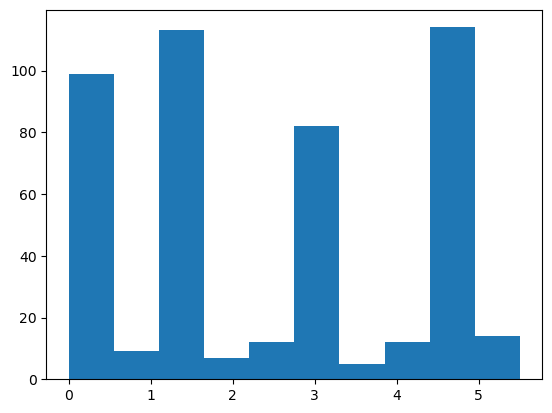

In [9]:
#plotting time
#histogram of directions for individuals 0
plt.hist(df_individuals[0]["direction"])

(array([1.331e+03, 0.000e+00, 3.600e+02, 0.000e+00, 1.010e+02, 1.000e+00,
        4.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([ 0.        ,  4.48207171,  8.96414343, 13.44621514, 17.92828685,
        22.41035857, 26.89243028, 31.37450199, 35.85657371, 40.33864542,
        44.82071713]),
 <BarContainer object of 10 artists>)

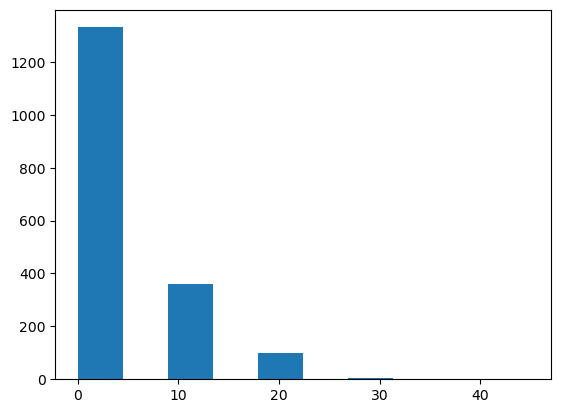

In [10]:
plt.hist(df_individuals[0]["distance"])

In [11]:
print("Total distance: " + str(np.sum(df_individuals[0]["distance"])) + " microns")

Total distance: 5437.851508939482 microns


(array([1.331e+03, 0.000e+00, 3.600e+02, 0.000e+00, 1.010e+02, 1.000e+00,
        4.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([   0.        ,  134.46215139,  268.92430279,  403.38645418,
         537.84860558,  672.31075697,  806.77290837,  941.23505976,
        1075.69721116, 1210.15936255, 1344.62151394]),
 <BarContainer object of 10 artists>)

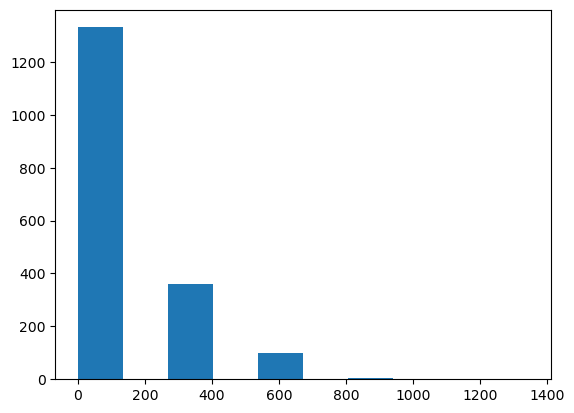

In [12]:
plt.hist(df_individuals[0]["speed"])

In [13]:
print("Average speed: " + str(np.mean(df_individuals[0]["speed"])) + " microns per second")

Average speed: 90.73167145060317 microns per second


Now, we'll look at the plots for the one that moved the most, individual 16.

(array([230., 135., 134., 275., 120., 272., 117., 226.,  46.,  75.]),
 array([0.        , 0.60875142, 1.21750284, 1.82625426, 2.43500569,
        3.04375711, 3.65250853, 4.26125995, 4.87001137, 5.47876279,
        6.08751421]),
 <BarContainer object of 10 artists>)

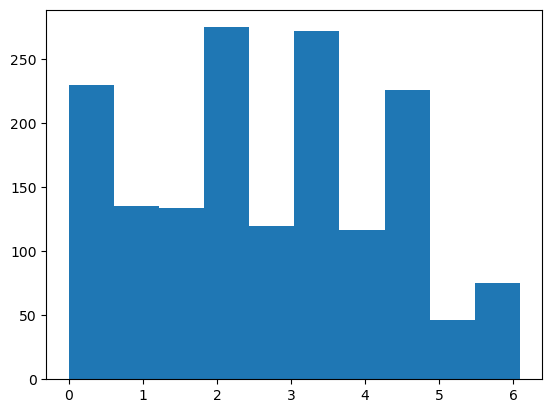

In [14]:
plt.hist(df_individuals[16]["direction"])

(array([439., 716., 291., 261.,  67.,  17.,   2.,   1.,   3.,   1.]),
 array([  0.        ,  10.75697211,  21.51394422,  32.27091633,
         43.02788845,  53.78486056,  64.54183267,  75.29880478,
         86.05577689,  96.812749  , 107.56972112]),
 <BarContainer object of 10 artists>)

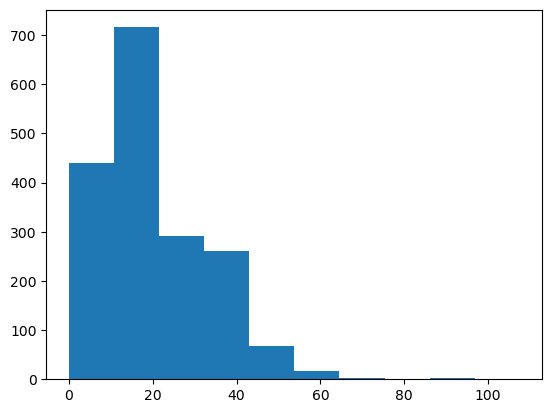

In [15]:
plt.hist(df_individuals[16]["distance"])

In [16]:
print("Total distance: " + str(np.sum(df_individuals[16]["distance"])) + " microns")

Total distance: 37177.47346849386 microns


(array([439., 716., 291., 261.,  67.,  17.,   2.,   1.,   3.,   1.]),
 array([   0.        ,  322.70916335,  645.41832669,  968.12749004,
        1290.83665339, 1613.54581673, 1936.25498008, 2258.96414343,
        2581.67330677, 2904.38247012, 3227.09163347]),
 <BarContainer object of 10 artists>)

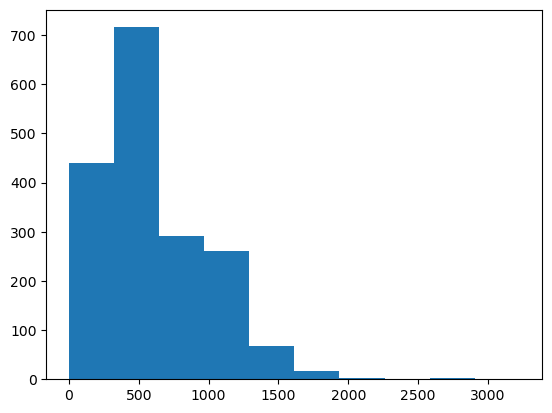

In [17]:
plt.hist(df_individuals[16]["speed"])

In [18]:
print("Average speed: " + str(np.mean(df_individuals[16]["speed"])) + " microns per second")

Average speed: 620.3137953586294 microns per second


<Axes: xlabel='direction', ylabel='Density'>

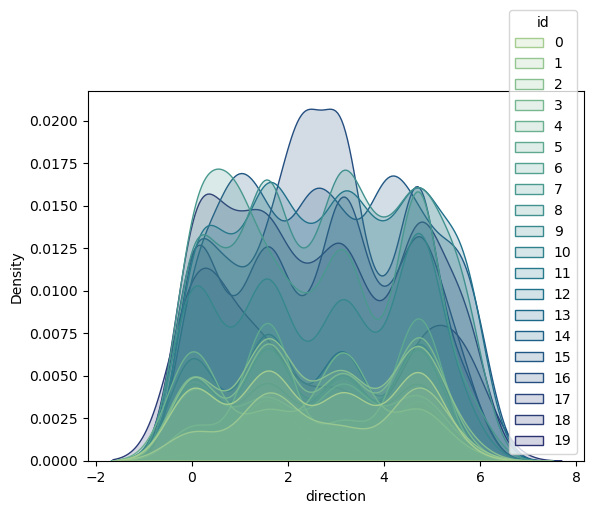

In [19]:
#aggregate plots time: just for experimentation
sns.kdeplot(data = df_new, x = "direction", hue = "id", palette = "crest", fill = True, alpha = 0.2)

<Axes: xlabel='distance', ylabel='Density'>

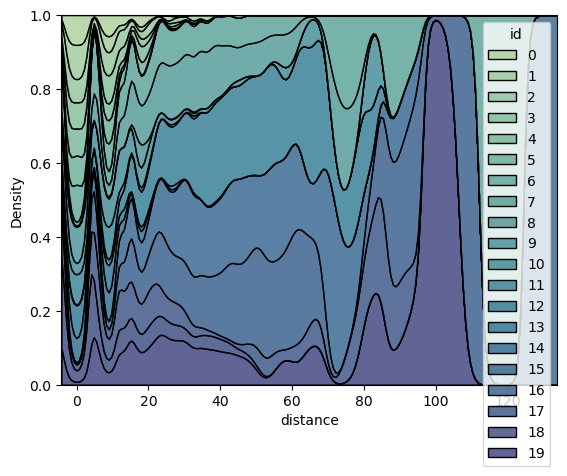

In [20]:
sns.kdeplot(data = df_new, x = "distance", hue = "id", palette = "crest", multiple="fill")

In [21]:
#summary statistics
df_new[["id", "width", "height", "direction", "speed"]].groupby("id").mean()

,width,height,direction,speed
id,,,,
0,12.351862,12.601445,2.493266,90.731671
1,11.657032,12.802668,2.852338,64.997063
2,14.167315,14.074486,2.615726,123.228512
3,11.702613,12.245136,2.625479,109.356917
4,12.117843,12.778766,2.158997,100.124573
5,12.436354,12.946637,2.893200,93.857627
6,12.044469,11.693163,2.436030,71.643810
7,11.768205,11.735964,2.459665,458.763563
8,12.200667,12.494719,2.843235,599.357158


In [22]:
df_new[["id", "distance"]].groupby("id").sum()

,distance
id,
0,5437.851509
1,3895.490633
2,7385.495472
3,6554.124553
4,6000.799385
5,5625.200437
6,4293.852327
7,27495.229517
8,35921.472336


In [23]:
def euclidean_distance(x1, y1, x2, y2):
    return np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

distance_changes = []
for i in ids:
    distance_changes.append(euclidean_distance(
        df_individuals[i].iloc[0]["x_center"],
        df_individuals[i].iloc[0]["y_center"],
        df_individuals[i].iloc[-1]["x_center"],
        df_individuals[i].iloc[-1]["y_center"],
    ))

In [24]:
df_summary = pd.concat([df_new[["id", "width", "height", "direction", "speed"]].groupby("id").mean(),
           df_new[["id", "distance"]].groupby("id").sum()], axis=1)
df_summary.columns = ["mean_width_pixels", "mean_height_pixels", "avg_direction_radians", 
                      "avg_speed_mps", "total_distance_microns"]
df_summary["distance_change"] = distance_changes
df_summary.to_csv("summary_test.csv")
df_summary

,mean_width_pixels,mean_height_pixels,avg_direction_radians,avg_speed_mps,total_distance_microns,distance_change
id,,,,,,
0,12.351862,12.601445,2.493266,90.731671,5437.851509,2.000000
1,11.657032,12.802668,2.852338,64.997063,3895.490633,1.500000
2,14.167315,14.074486,2.615726,123.228512,7385.495472,2.000000
3,11.702613,12.245136,2.625479,109.356917,6554.124553,9.219544
4,12.117843,12.778766,2.158997,100.124573,6000.799385,0.707107
5,12.436354,12.946637,2.893200,93.857627,5625.200437,1.000000
6,12.044469,11.693163,2.436030,71.643810,4293.852327,1.581139
7,11.768205,11.735964,2.459665,458.763563,27495.229517,507.631756
8,12.200667,12.494719,2.843235,599.357158,35921.472336,174.459881


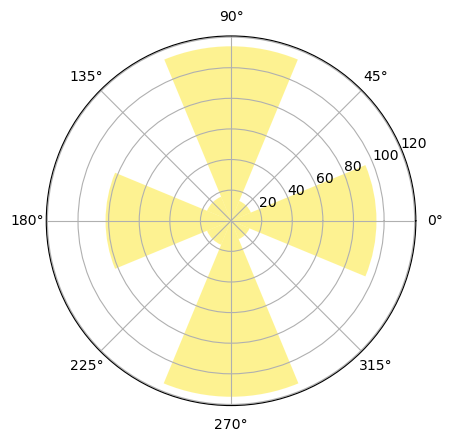

In [25]:
def get_direction_numbers(df):
    radii = np.zeros(8)
    for i in range(len(df)):
        d = df.iloc[i]["direction"]
        if d < (np.pi / 8) or d >= (15 * np.pi / 8):
            radii[0] += 1
        elif d < (3 * np.pi / 8) and d >= (np.pi / 8):
            radii[1] += 1
        elif d < (5 * np.pi / 8) and d >= (3 * np.pi / 8):
            radii[2] += 1
        elif d < (7 * np.pi / 8) and d >= (5 * np.pi / 8):
            radii[3] += 1
        elif d < (9 * np.pi / 8) and d >= (7 * np.pi / 8):
            radii[4] += 1
        elif d < (11 * np.pi / 8) and d >= (9 * np.pi / 8):
            radii[5] += 1
        elif d < (13 * np.pi / 8) and d >= (11 * np.pi / 8):
            radii[6] += 1
        elif d < (15 * np.pi / 8) and d >= (13 * np.pi / 8):
            radii[7] += 1

    return radii

N = 8
theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)
radii = get_direction_numbers(df_individuals[0])
width = np.pi / 4 * np.ones(8)

colors = plt.colormaps["viridis"](radii / 10.)

ax = plt.subplot(projection='polar')
ax.bar(theta, radii, width=width, bottom=0.0, color=colors, alpha=0.5)

plt.show()

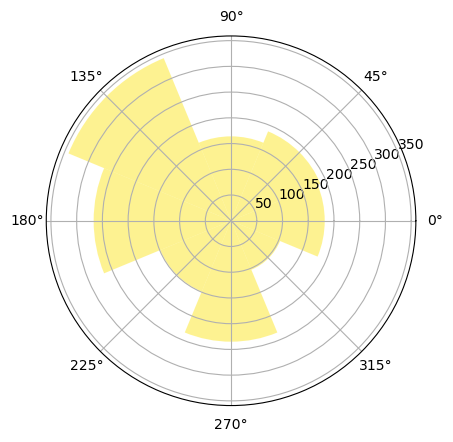

In [26]:
radii = get_direction_numbers(df_individuals[16])

ax = plt.subplot(projection='polar')
ax.bar(theta, radii, width=width, bottom=0.0, color=colors, alpha=0.5)

plt.show()